Accuracy of SVM on test set: 1.00


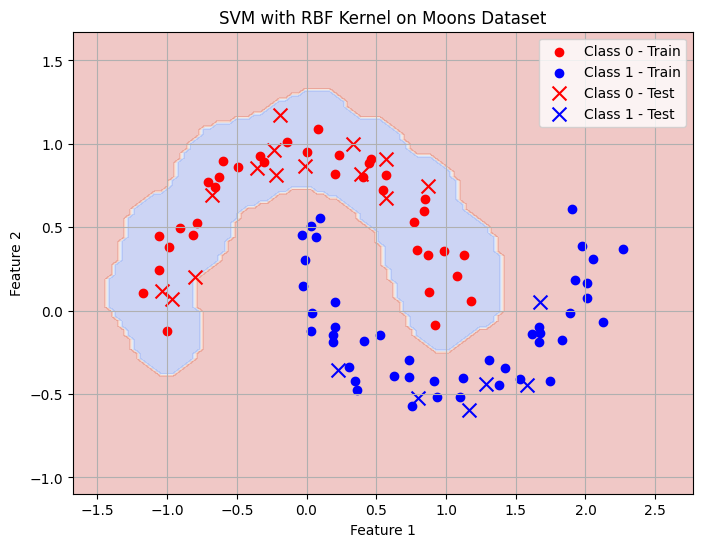

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. إنشاء بيانات الـ "Moons"
# n_samples: عدد النقاط
# noise: مدى تشتت النقاط (لو كان 0، لكانت مثالية)
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# تقسيم البيانات إلى تدريب واختبار (مهم جداً لتقييم الموديل)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تعديل الموديل ليكون أكثر "ذكاءً" في المنحنيات
# قمنا برفع Gamma إلى 5 و C إلى 100 لزيادة الدقة
model = SVC(kernel='rbf', C=100.0, gamma=40) 
model.fit(X_train, y_train)

# 3. تقييم الموديل (اختياري)
y_pred = model.predict(X_test)
print(f"Accuracy of SVM on test set: {accuracy_score(y_test, y_pred):.2f}")

# 4. رسم حدود القرار (Decision Boundary)
plt.figure(figsize=(8, 6))

# تحديد حدود الرسم البياني
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# إنشاء شبكة من النقاط لتقييم الموديل عليها
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# التنبؤ بالصنف لكل نقطة في الشبكة (هذا ما يشكل لون الخلفية)
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# رسم مناطق القرار كخلفية ملونة
plt.contourf(xx, yy, Z, alpha=0.29, cmap=plt.cm.coolwarm)

# رسم نقاط البيانات الأصلية (نقاط التدريب والاختبار)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', label='Class 0 - Train')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='blue', label='Class 1 - Train')
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color='red', marker='x', s=100, label='Class 0 - Test')
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='blue', marker='x', s=100, label='Class 1 - Test')


plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM with RBF Kernel on Moons Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# Overfitting & Underfitting !!

# أهم ما يجب أن تعرفه عن Train Validation Test Splits من Machine Learning #22

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

x, y = iris.data, iris.target
print(x, y)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

cl1 = LogisticRegression(max_iter=1000, random_state=42)
cl2 = DecisionTreeClassifier(random_state=42)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=30, shuffle=True, stratify=y)

from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

var1 = cross_val_score(cl1, X_train, y_train, cv=kfold)
var2 = cross_val_score(cl2, X_train, y_train, cv=kfold)   



In [42]:
print(f"the mean for classifier 1 is : {np.mean(var1) : .2f}")
print(f"the mean for classifier 2 is : {np.mean(var2) : .2f}")

the mean for classifier 1 is :  0.97
the mean for classifier 2 is :  0.98


In [43]:
# Handling Missing !
# Data Preprocessing - Handling Missing Values بالعربي || Machine Learning #26

titanic = pd.read_csv('train.csv')
print(titanic)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [44]:
missing_val = titanic.isnull().sum()
print(missing_val)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [52]:
# Delete the column or the row !

# Imputation
# replace the value of NaN by mean or median mode
# predict model

from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(titanic, test_size=0.3, random_state=42)

train_data['Cabin'].fillna('Unknown', inplace=True)
test_data['Cabin'].fillna('Unknown', inplace=True)
print(train_data['Cabin'])
print("*" * 20)
print(train_data.isnull().sum())

445        A34
650    Unknown
172    Unknown
450    Unknown
314    Unknown
        ...   
106    Unknown
270    Unknown
860    Unknown
435    B96 B98
102        D26
Name: Cabin, Length: 623, dtype: object
********************
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            124
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         1
dtype: int64


C:\Users\djabe\AppData\Local\Temp\ipykernel_9792\664066511.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Cabin'].fillna('Unknown', inplace=True)
C:\Users\djabe\AppData\Local\Temp\ipykernel_9792\664066511.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

$$Age$$

In [53]:
train_data['Age'].median()

np.float64(28.0)

In [63]:
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
print(train_data['Age'])

train_data['Embarked'].mode()[0]

train_data['Embarked'].fillna(train_data['Embarked'].mode()[0], inplace=True)
test_data['Embarked'].fillna(test_data['Embarked'].mode()[0], inplace=True)
print("*" * 20)
print(train_data.isnull().sum())
print("*" * 20)
print(test_data.isnull().sum())

445     4.0
650    28.0
172     1.0
450    36.0
314    43.0
       ... 
106    21.0
270    28.0
860    41.0
435    14.0
102    21.0
Name: Age, Length: 623, dtype: float64
********************
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
********************
PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age            53
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin           0
Embarked        0
dtype: int64


C:\Users\djabe\AppData\Local\Temp\ipykernel_9792\2439490871.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
C:\Users\djabe\AppData\Local\Temp\ipykernel_9792\2439490871.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [ ]:
# Cross Validation - Missing Values Example بالعربي || Machine Learning #28
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


titanic = pd.read_csv('train.csv')
print(titanic)
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(titanic, test_size=0.3, random_state=42)